In [ ]:
pip install pandas scikit-learn nltk matplotlib ollama

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 9.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Professional-resume-Shirisha.pdf to Professional-resume-Shirisha.pdf


In [ ]:
import PyPDF2

# Get uploaded filename
filename = list(uploaded.keys())[0]

with open(filename, "rb") as f:
    reader = PyPDF2.PdfReader(f)
    resume_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            resume_text += text

print("Resume loaded successfully ✅")

Resume loaded successfully ✅


In [ ]:
job_description = """
We are hiring a Dotnet Developer Engineer with strong C# skills,
ADO.NET experience, SQL knowledge and experience with Azure.
"""

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [ ]:
def compute_similarity(resume, job_desc):

    documents = [
        clean_text(resume),
        clean_text(job_desc)
    ]

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(documents)

    similarity = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )

    return round(float(similarity[0][0]) * 100, 2)

In [ ]:
def extract_keywords(text):
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=30
    )

    tfidf_matrix = vectorizer.fit_transform([clean_text(text)])

    return set(vectorizer.get_feature_names_out())


def skill_gap_analysis(resume, job_desc):

    resume_keywords = extract_keywords(resume)
    job_keywords = extract_keywords(job_desc)

    matched_skills = resume_keywords.intersection(job_keywords)
    missing_skills = job_keywords - resume_keywords

    return matched_skills, missing_skills

In [ ]:
similarity_score = compute_similarity(
    resume_text,
    job_description
)

matched_skills, missing_skills = skill_gap_analysis(
    resume_text,
    job_description
)

print("Match Score:", similarity_score, "%")
print("\nMatched Skills:", matched_skills)
print("\nMissing Skills:", missing_skills)

Match Score: 16.26 %

Matched Skills: {'developer', 'experience', 'sql', 'skills'}

Missing Skills: {'adonet', 'hiring', 'engineer', 'dotnet', 'strong', 'azure', 'knowledge'}


In [ ]:
#LLM feedback generation

In [ ]:
!pip install transformers torch accelerate

In [ ]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

In [ ]:
def generate_resume_feedback(resume, job_desc, similarity, missing_skills):

    prompt = f"""
Resume:
{resume}

Job Description:
{job_desc}

Match Score: 16.26%

Missing Skills: {'adonet', 'hiring', 'engineer', 'dotnet', 'strong', 'azure', 'knowledge'}
"""
    response = generator(
        prompt,
        max_length=512,
        do_sample=True,
        temperature=0.7
    )

    return response[0]["generated_text"]

In [ ]:
feedback = generate_resume_feedback(
    resume_text,
    job_description,
    similarity_score,
    missing_skills
)

print(feedback)

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Resume:
ACCENTURE | 09/2024 – 09/25  
 
Metrolinx  (Fare Management System) - CANADA  
Team Size: 30 (L3 Support) | Program Size: 300+  
 
Responsibilities & Impacts : 
• Provided production and technical support for a fare management system 
used by millions of daily commuters  across Ontario transit networks.  
• Technology used: C#, ASP.NET 4.8 x, SQL  Server , Azure DevOps, React JS, 
Postman, Event Viewer  
• Resolved 15 –20 production incidents per month, reducing ticket backlog by 
30% and improving SLA adherence to 98%. 
• Performed root cause analysis using Event Viewer, logs, and SQL tracing, 
reducing recurring defects by 35%. 
• Developed and optimized SQL stored procedures, views, joins, and triggers, 
improving data retrieval performance by 30%. 
• Experience on migration on old technology à new technology.  
• Expe rience on Agile methodologies, c onduct code reviews and manage the 
process. Demonstrated expertise in software requirements and designed use 
case diagrams

In [ ]:
#Step 1 — Create Market Salary Dataset

In [ ]:
import pandas as pd

salary_data = {
    "role": [
        "Data Analyst", "Data Analyst", "ML Engineer", "ML Engineer",
        "Data Scientist", "Data Scientist", "Python Developer", "Python Developer"
    ],
    "city": [
        "Bangalore", "Hyderabad", "Bangalore", "Hyderabad",
        "Bangalore", "Pune", "Bangalore", "Remote"
    ],
    "avg_lpa": [
        8, 7, 14, 12,
        16, 13, 10, 9
    ]
}

df_salary = pd.DataFrame(salary_data)
df_salary

,role,city,avg_lpa
0,Data Analyst,Bangalore,8
1,Data Analyst,Hyderabad,7
2,ML Engineer,Bangalore,14
3,ML Engineer,Hyderabad,12
4,Data Scientist,Bangalore,16
5,Data Scientist,Pune,13
6,Python Developer,Bangalore,10
7,Python Developer,Remote,9


In [ ]:
#Step 2 — Analytics Layer

In [ ]:
def get_indian_market_salary(role, city):
    result = df_salary[
        (df_salary["role"] == role) &
        (df_salary["city"] == city)
    ]

    if not result.empty:
        return result["avg_lpa"].values[0]
    else:
        return None

In [ ]:
!pip install transformers torch accelerate

In [ ]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="google/flan-t5-large",
    device_map="auto"
)

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

In [ ]:
def indian_salary_agent_free(resume_summary, role, city, experience_years):

    prompt = f"""
    You are a salary expert for the Indian tech market.

    Candidate:
    Role: {role}
    City: {city}
    Experience: {experience_years} years
    Summary: {resume_summary}

    Provide:
    1. Expected salary range in LPA
    2. Market comparison
    3. Negotiation strategy
    4. Skills to increase salary
    5. Risk factors
    """

    result = generator(
        prompt,
        max_new_tokens=400,
        do_sample=False
    )

    return result[0]["generated_text"]

In [ ]:
resume_summary = """
Python developer with 3 years experience in Django, REST APIs,
Machine Learning basics, deployed apps on AWS.
"""

output = indian_salary_agent_free(
    resume_summary,
    role="Python Developer",
    city="Bangalore",
    experience_years=3
)

print(output)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



    You are a salary expert for the Indian tech market.

    Candidate:
    Role: Python Developer
    City: Bangalore
    Experience: 3 years
    Summary: 
Python developer with 3 years experience in Django, REST APIs,
Machine Learning basics, deployed apps on AWS.


    Provide:
    1. Expected salary range in LPA
    2. Market comparison
    3. Negotiation strategy
    4. Skills to increase salary
    5. Risk factors
    


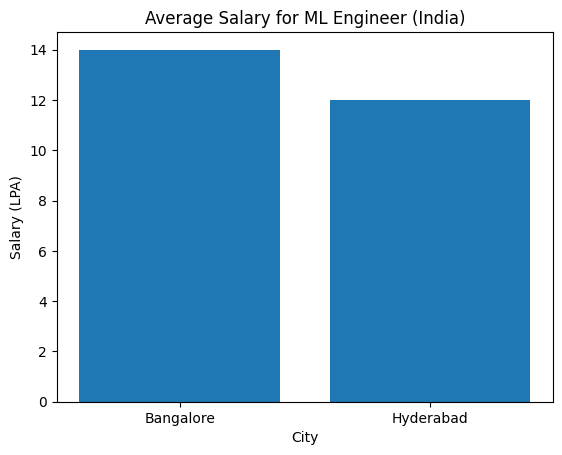

In [ ]:
import matplotlib.pyplot as plt

def plot_role_salary(role):
    subset = df_salary[df_salary["role"] == role]

    plt.bar(subset["city"], subset["avg_lpa"])
    plt.title(f"Average Salary for {role} (India)")
    plt.xlabel("City")
    plt.ylabel("Salary (LPA)")
    plt.show()

plot_role_salary("ML Engineer")

In [ ]:
class IndianMarketAgent:
    def analyze(self, role, city):
        return get_indian_market_salary(role, city)

class NegotiationAgent:
    def generate(self, resume, role, city, exp):
        return indian_salary_agent(resume, role, city, exp)

class SalaryOrchestrator:
    def run(self, resume, role, city, exp):
        market_data = IndianMarketAgent().analyze(role, city)
        strategy = NegotiationAgent().generate(resume, role, city, exp)
        return strategy

In [1]:
#Job Clustering using KMeans

In [2]:
!pip install scikit-learn pandas matplotlib seaborn

In [3]:
import pandas as pd

jobs = [
    "Looking for Python developer with Django and REST API experience",
    "Machine Learning engineer with TensorFlow and deep learning background",
    "Data analyst skilled in SQL, Excel, Power BI and Python",
    "Backend developer with Flask, APIs and cloud deployment",
    "Data scientist with NLP, statistics and predictive modeling",
    "AI engineer with transformers, PyTorch and model deployment",
    "Business analyst with reporting and dashboard creation",
    "ML engineer with computer vision and neural networks",
    "Python developer with automation scripting experience",
    "Data analyst with Tableau and data visualization skills"
]

df = pd.DataFrame({"job_description": jobs})
df

,job_description
0,Looking for Python developer with Django and R...
1,Machine Learning engineer with TensorFlow and ...
2,"Data analyst skilled in SQL, Excel, Power BI a..."
3,"Backend developer with Flask, APIs and cloud d..."
4,"Data scientist with NLP, statistics and predic..."
5,"AI engineer with transformers, PyTorch and mod..."
6,Business analyst with reporting and dashboard ...
7,ML engineer with computer vision and neural ne...
8,Python developer with automation scripting exp...
9,Data analyst with Tableau and data visualizati...


In [6]:
#STEP 3 — Convert Text to Numerical Features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["job_description"])

In [7]:
#Apply KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

df["cluster"] = kmeans.labels_
df

,job_description,cluster
0,Looking for Python developer with Django and R...,2
1,Machine Learning engineer with TensorFlow and ...,2
2,"Data analyst skilled in SQL, Excel, Power BI a...",1
3,"Backend developer with Flask, APIs and cloud d...",0
4,"Data scientist with NLP, statistics and predic...",1
5,"AI engineer with transformers, PyTorch and mod...",0
6,Business analyst with reporting and dashboard ...,1
7,ML engineer with computer vision and neural ne...,2
8,Python developer with automation scripting exp...,2
9,Data analyst with Tableau and data visualizati...,1


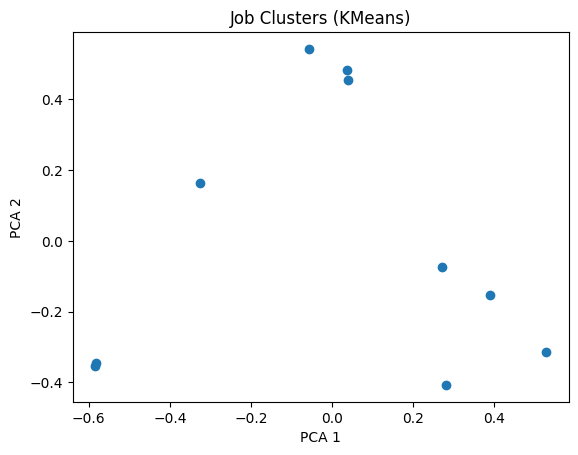

In [8]:
#STEP 5 — Visualize Clusters (2D Projection)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title("Job Clusters (KMeans)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [9]:
#STEP 6 — Interpret Clusters
import numpy as np

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(3):
    print(f"\nCluster {i} Top Keywords:")
    for ind in order_centroids[i, :5]:
        print(terms[ind])


Cluster 0 Top Keywords:
deployment
transformers
model
pytorch
ai

Cluster 1 Top Keywords:
data
analyst
reporting
dashboard
business

Cluster 2 Top Keywords:
experience
python
developer
learning
engineer


In [10]:
#You may get clusters like: Cluster 0 → Python/Backend roles, Cluster 1 → ML/AI roles, Cluster 2 → Data Analyst roles

In [11]:
#We can: Match resume cluster vs job cluster, Recommend best-fit job group, Identify skill gaps per cluster

In [13]:
#Sample data Job Clustering + Salary Analytics
import pandas as pd

jobs_data = [
    ("Python developer with Django and REST APIs", 10),
    ("Backend developer with Flask and AWS deployment", 12),
    ("Machine Learning engineer with TensorFlow and NLP", 18),
    ("Data scientist with predictive modeling and statistics", 20),
    ("Data analyst with SQL and Power BI", 8),
    ("Business analyst with dashboard reporting", 7),
    ("AI engineer with transformers and deep learning", 22),
    ("ML engineer with computer vision", 17),
    ("Python automation scripting developer", 9),
    ("Data analyst with Tableau and Excel", 8),
]

df = pd.DataFrame(jobs_data, columns=["job_description", "salary_lpa"])
df

,job_description,salary_lpa
0,Python developer with Django and REST APIs,10
1,Backend developer with Flask and AWS deployment,12
2,Machine Learning engineer with TensorFlow and NLP,18
3,Data scientist with predictive modeling and st...,20
4,Data analyst with SQL and Power BI,8
5,Business analyst with dashboard reporting,7
6,AI engineer with transformers and deep learning,22
7,ML engineer with computer vision,17
8,Python automation scripting developer,9
9,Data analyst with Tableau and Excel,8


In [14]:
!pip install sentence-transformers

In [15]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["job_description"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
#STEP 3 — KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(embeddings)

df

,job_description,salary_lpa,cluster
0,Python developer with Django and REST APIs,10,2
1,Backend developer with Flask and AWS deployment,12,2
2,Machine Learning engineer with TensorFlow and NLP,18,0
3,Data scientist with predictive modeling and st...,20,0
4,Data analyst with SQL and Power BI,8,1
5,Business analyst with dashboard reporting,7,1
6,AI engineer with transformers and deep learning,22,0
7,ML engineer with computer vision,17,0
8,Python automation scripting developer,9,2
9,Data analyst with Tableau and Excel,8,1


In [17]:
#STEP 4 — Cluster-Based Salary Analysis
cluster_salary = df.groupby("cluster")["salary_lpa"].agg(
    ["mean", "min", "max", "count"]
)

cluster_salary

,mean,min,max,count
cluster,,,,
0,19.250000,17,22,4
1,7.666667,7,8,3
2,10.333333,9,12,3


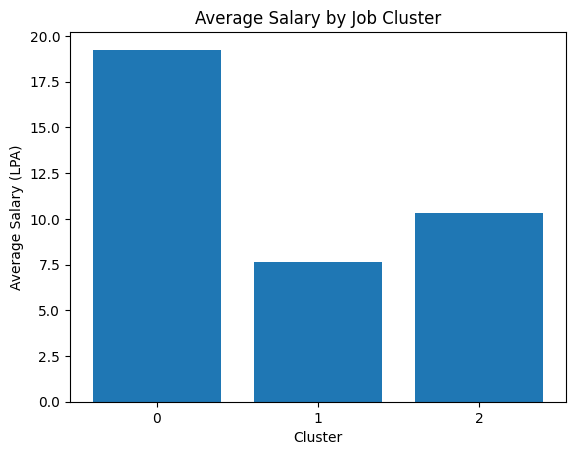

In [18]:
#STEP 5 — Visualize Salary by Cluster
import matplotlib.pyplot as plt

plt.figure()
plt.bar(cluster_salary.index.astype(str), cluster_salary["mean"])
plt.xlabel("Cluster")
plt.ylabel("Average Salary (LPA)")
plt.title("Average Salary by Job Cluster")
plt.show()

In [21]:
#STEP 6 — Interpret Clusters

for c in df["cluster"].unique():
    print(f"\nCluster {c}")
    print(df[df["cluster"] == c]["job_description"].values)


Cluster 2
['Python developer with Django and REST APIs'
 'Backend developer with Flask and AWS deployment'
 'Python automation scripting developer']

Cluster 0
['Machine Learning engineer with TensorFlow and NLP'
 'Data scientist with predictive modeling and statistics'
 'AI engineer with transformers and deep learning'
 'ML engineer with computer vision']

Cluster 1
['Data analyst with SQL and Power BI'
 'Business analyst with dashboard reporting'
 'Data analyst with Tableau and Excel']


In [23]:
#with salary
for c in df["cluster"].unique():
    print(f"\nCluster {c}")
    print(df[df["cluster"] == c][["job_description", "salary_lpa"]])


Cluster 2
                                   job_description  salary_lpa
0       Python developer with Django and REST APIs          10
1  Backend developer with Flask and AWS deployment          12
8            Python automation scripting developer           9

Cluster 0
                                     job_description  salary_lpa
2  Machine Learning engineer with TensorFlow and NLP          18
3  Data scientist with predictive modeling and st...          20
6    AI engineer with transformers and deep learning          22
7                   ML engineer with computer vision          17

Cluster 1
                             job_description  salary_lpa
4         Data analyst with SQL and Power BI           8
5  Business analyst with dashboard reporting           7
9        Data analyst with Tableau and Excel           8


In [24]:
#Average salary
cluster_salary = df.groupby("cluster")["salary_lpa"].mean()
print(cluster_salary)

cluster
0    19.250000
1     7.666667
2    10.333333
Name: salary_lpa, dtype: float64
